# B2 — Supply Chain Network Design

Rémi Brenaut, Edouard André, Quentin Lauret — SCIA 2027

Le Supply Chain Network Design (SCND) est un problème de localisation-allocation :
il s'agit de choisir quels entrepôts ouvrir parmi un ensemble de candidats,
puis d'affecter chaque client à un entrepôt ouvert, en minimisant les coûts fixes
d'ouverture et les coûts de transport, sous des contraintes de capacité.

Ce notebook modélise le problème comme un CFLP (Capacitated Facility Location Problem)
et le résout avec quatre approches : CP-SAT, PLNE, GRASP et ALNS.
Les instances de test proviennent de l'OR-Library de Beasley (1988).

## Imports

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import numpy as np
import pulp
import random
import time

from ortools.sat.python import cp_model

## Données : OR-Library (Beasley 1988)

Les instances CAP sont des benchmarks standards pour le CFLP.
Chaque fichier contient le nombre d'entrepôts candidats et de clients,
la capacité et le coût fixe de chaque entrepôt,
puis pour chaque client sa demande et le coût de transport vers chaque entrepôt.

Le fichier `capopt.txt` fournit l'optimum connu pour chaque instance,
calculé et vérifié dans la littérature. Cela permet de mesurer le gap
de chaque méthode par rapport à la solution optimale prouvée.

## Parser

In [4]:
def parse_cap(filepath):
    with open(filepath) as f:
        tokens = f.read().split()
    
    idx = 0
    n_warehouses = int(tokens[idx]); idx += 1
    n_customers  = int(tokens[idx]); idx += 1

    capacity  = []
    fix_cost  = []
    for _ in range(n_warehouses):
        capacity.append(float(tokens[idx]));  idx += 1
        fix_cost.append(float(tokens[idx]));  idx += 1

    demand        = []
    transport     = []  # transport[i][j] = cost from customer i to warehouse j
    for _ in range(n_customers):
        demand.append(float(tokens[idx])); idx += 1
        costs = []
        for _ in range(n_warehouses):
            costs.append(float(tokens[idx])); idx += 1
        transport.append(costs)

    return n_warehouses, n_customers, capacity, fix_cost, demand, transport

In [5]:
def parse_capopt(filepath):
    optima = {}
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("Note") or line.startswith("Data"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                float(parts[0])  # continuation line (no instance name)
                continue
            except ValueError:
                pass
            name = parts[0]
            try:
                val = float(parts[1])
                if name not in optima:
                    optima[name] = val
            except (ValueError, IndexError):
                continue
    return optima

known_optima = parse_capopt("data/capopt.txt")
print(f"Loaded {len(known_optima)} known optima")

Loaded 40 known optima


In [6]:
n_w, n_c, cap, fix, dem, trans = parse_cap("data/cap134.txt")

print(f"{n_w} warehouses, {n_c} customers")
print(f"Warehouse 0 capacity: {cap[0]}")
print(f"Warehouse 10 fixed cost: {fix[10]}")
print(f"Customer 0 demand: {dem[0]}")
print(f"Transport cost customer 0 to warehouse 0: {trans[0][0]}")

50 warehouses, 50 customers
Warehouse 0 capacity: 58268.0
Warehouse 10 fixed cost: 25000.0
Customer 0 demand: 146.0
Transport cost customer 0 to warehouse 0: 2609.75


## Modèle CP-SAT

Le problème CFLP est modélisé avec deux types de variables de décision binaires :
`open[j]` indique si l'entrepôt j est ouvert, et `assign[i][j]` indique si le
client i est servi par l'entrepôt j.

Les trois contraintes sont les suivantes. Premièrement, chaque client est affecté
à exactement un entrepôt (couverture totale). Deuxièmement, un client ne peut être
affecté qu'à un entrepôt ouvert (cohérence). Troisièmement, la demande totale
affectée à chaque entrepôt ne dépasse pas sa capacité.

L'objectif est de minimiser la somme des coûts fixes d'ouverture et des coûts
de transport.

CP-SAT travaille exclusivement avec des entiers : tous les coûts sont multipliés
par 100 (SCALE) avant d'être passés au solveur, puis divisés en sortie.

In [7]:
def solve_cflp(n_w, n_c, cap, fix_cost, demand, transport, known_opt=None, verbose=True):
    model = cp_model.CpModel()
    
    # --- Scaling (CP-SAT works with integers) ---
    SCALE = 100
    fix_cost_int   = [int(f * SCALE) for f in fix_cost]
    transport_int  = [[int(transport[i][j] * SCALE) for j in range(n_w)] for i in range(n_c)]
    demand_int     = [int(d) for d in demand]
    cap_int        = [int(c) for c in cap]

    # --- Decision variables ---
    # open_w[j] = 1 if warehouse j is opened
    open_w = [model.NewBoolVar(f'open_{j}') for j in range(n_w)]

    # assign[i][j] = 1 if customer i is served by warehouse j
    assign = [[model.NewBoolVar(f'assign_{i}_{j}') 
               for j in range(n_w)] for i in range(n_c)]

    # --- Constraints ---

    # 1. Each customer is served by exactly one warehouse
    for i in range(n_c):
        model.AddExactlyOne(assign[i][j] for j in range(n_w))

    # 2. A customer can only be assigned to an OPEN warehouse
    for i in range(n_c):
        for j in range(n_w):
            model.AddImplication(assign[i][j], open_w[j])

    # 3. Capacity: total demand assigned to j does not exceed its capacity
    for j in range(n_w):
        model.Add(
            sum(demand_int[i] * assign[i][j] for i in range(n_c)) <= cap_int[j] * open_w[j]
        )

    # --- Objective: minimize fixed cost + transport cost ---
    total_cost = (
        sum(fix_cost_int[j] * open_w[j] for j in range(n_w)) +
        sum(transport_int[i][j] * assign[i][j] for i in range(n_c) for j in range(n_w))
    )
    model.Minimize(total_cost)

    # --- Solve ---
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60.0
    status = solver.Solve(model)

    # --- Display ---
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        if verbose:
            print(f"Status: {'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'}")
            print(f"Total cost: {solver.ObjectiveValue() / SCALE:.2f}")
            if known_opt is not None:
                print(f"Known optimum: {known_opt:.2f}")
            print()
            
            open_warehouses = [j for j in range(n_w) if solver.Value(open_w[j])]
            print(f"Open warehouses ({len(open_warehouses)}): {open_warehouses}")
            
            print("\nCustomer assignment:")
            for i in range(n_c):
                for j in range(n_w):
                    if solver.Value(assign[i][j]):
                        print(f"  Customer {i:2d} -> Warehouse {j:2d}  "
                              f"(demand={demand[i]:.0f}, cost={transport[i][j]:.2f})")
    else:
        if verbose:
            print("No solution found.")

    return solver, open_w, assign

In [8]:
n_w, n_c, cap, fix, dem, trans = parse_cap("data/cap134.txt")
solver, open_w, assign = solve_cflp(n_w, n_c, cap, fix, dem, trans, known_opt=known_optima.get("cap134"))

Status: OPTIMAL
Total cost: 928941.67
Known optimum: 928941.75

Open warehouses (4): [22, 26, 36, 45]

Customer assignment:
  Customer  0 -> Warehouse 22  (demand=146, cost=5219.50)
  Customer  1 -> Warehouse 22  (demand=87, cost=2296.80)
  Customer  2 -> Warehouse 22  (demand=672, cost=9828.00)
  Customer  3 -> Warehouse 36  (demand=1337, cost=15191.66)
  Customer  4 -> Warehouse 22  (demand=31, cost=1133.05)
  Customer  5 -> Warehouse 22  (demand=559, cost=7029.43)
  Customer  6 -> Warehouse 36  (demand=2370, cost=40319.62)
  Customer  7 -> Warehouse 22  (demand=1089, cost=12741.30)
  Customer  8 -> Warehouse 22  (demand=33, cost=1395.90)
  Customer  9 -> Warehouse 22  (demand=32, cost=928.80)
  Customer 10 -> Warehouse 22  (demand=5495, cost=25277.00)
  Customer 11 -> Warehouse 22  (demand=904, cost=2463.40)
  Customer 12 -> Warehouse 22  (demand=1466, cost=10371.95)
  Customer 13 -> Warehouse 22  (demand=143, cost=2434.57)
  Customer 14 -> Warehouse 22  (demand=615, cost=14621.62)


## Visualisation spatiale : réseau d'affectation

Les instances CAP ne fournissent pas de coordonnées géographiques.
On reconstruit une disposition 2D par MDS (Multidimensional Scaling) classique :
la matrice de distances est construite à partir des coûts de transport entre
clients et entrepôts (distance économique), puis projetée en 2D par décomposition
propre. Les nœuds proches sur le graphe ont des coûts de transport similaires.

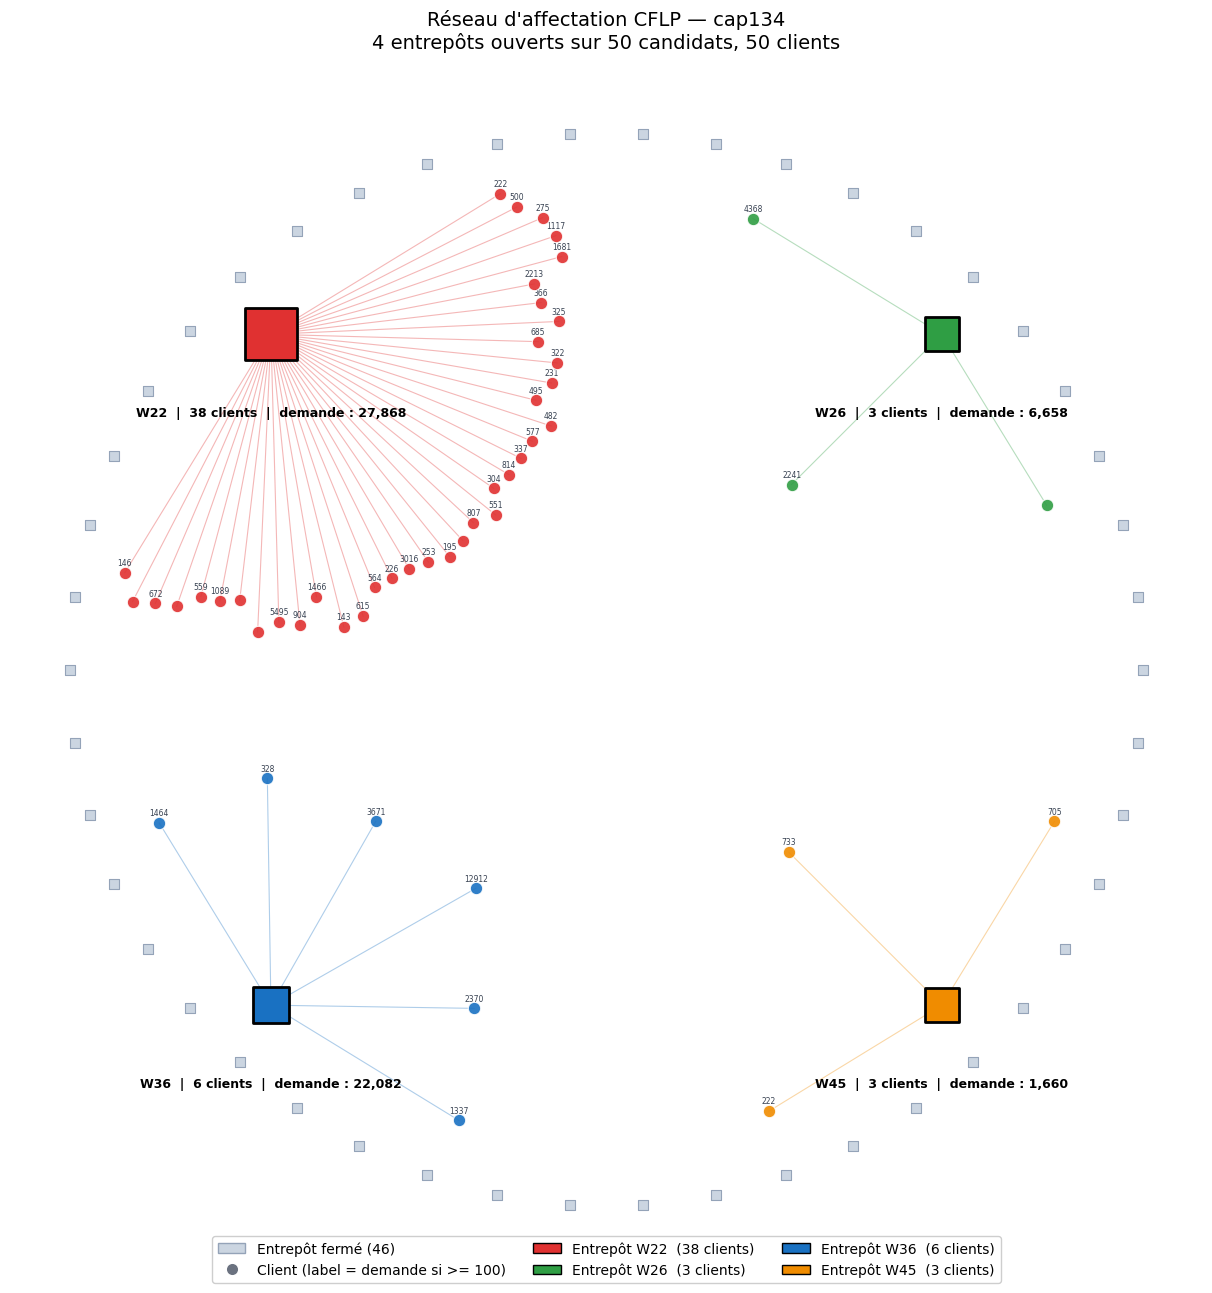

In [23]:
open_set_sp = [j for j in range(n_w) if solver.Value(open_w[j])]
palette     = ["#E03131", "#2F9E44", "#1971C2", "#F08C00"]

client_wh = {}
for i in range(n_c):
    for j in range(n_w):
        if solver.Value(assign[i][j]):
            client_wh[i] = j

clusters = {wh: [] for wh in open_set_sp}
for i, wh in client_wh.items():
    clusters[wh].append(i)

fig, ax = plt.subplots(figsize=(13, 13))
ax.set_aspect("equal")
ax.axis("off")

wh_positions = {}
wh_centers = [
    (-4.5,  4.5),
    ( 4.5,  4.5),
    (-4.5, -4.5),
    ( 4.5, -4.5),
]
for k, wh in enumerate(open_set_sp):
    wh_positions[wh] = wh_centers[k]

np.random.seed(42)
client_positions = {}
for k, wh in enumerate(open_set_sp):
    cx, cy = wh_positions[wh]
    clients = clusters[wh]
    n = len(clients)
    angle_center = np.arctan2(-cy, -cx)
    spread = np.pi * 0.85
    angles = np.linspace(angle_center - spread/2,
                         angle_center + spread/2, n)
    radius = 2.8 + 0.4 * (n / 15)
    for i, a in zip(clients, angles):
        r = radius + np.random.uniform(-0.25, 0.25)
        client_positions[i] = (cx + r * np.cos(a),
                               cy + r * np.sin(a))

for i, wh in client_wh.items():
    k = open_set_sp.index(wh)
    cx_i, cy_i = client_positions[i]
    wx, wy = wh_positions[wh]
    ax.plot([cx_i, wx], [cy_i, wy],
            color=palette[k], linewidth=0.8, alpha=0.35, zorder=1)

for i in range(n_c):
    k = open_set_sp.index(client_wh[i])
    cx_i, cy_i = client_positions[i]
    ax.scatter(cx_i, cy_i, s=80, color=palette[k],
               edgecolors="white", linewidths=0.8,
               zorder=3, alpha=0.9)
    if dem[i] >= 100:
        ax.annotate(f"{int(dem[i])}",
                    (cx_i, cy_i), fontsize=5.5, color="#374151",
                    ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points")

for k, wh in enumerate(open_set_sp):
    wx, wy = wh_positions[wh]
    n_clients = len(clusters[wh])
    size = 500 + n_clients * 25
    ax.scatter(wx, wy, s=size, color=palette[k],
               marker="s", edgecolors="black", linewidths=2,
               zorder=5)
    total_dem = sum(dem[i] for i in clusters[wh])
    ax.annotate(
        f"W{wh}  |  {n_clients} clients  |  demande : {int(total_dem):,}",
        (wx, wy),
        xytext=(0, -52),
        textcoords="offset points",
        fontsize=9, fontweight="bold",
        ha="center", va="top", color="black"
    )

closed_sp = [j for j in range(n_w) if j not in open_set_sp]
n_closed  = len(closed_sp)
for idx, j in enumerate(closed_sp):
    angle = 2 * np.pi * idx / n_closed
    r = 7.2
    ax.scatter(r * np.cos(angle), r * np.sin(angle),
               s=55, color="#CBD5E1", marker="s",
               edgecolors="#94A3B8", linewidths=0.8, zorder=2)

legend_handles = [
    Patch(facecolor="#CBD5E1", edgecolor="#94A3B8",
          label=f"Entrepôt fermé ({len(closed_sp)})"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#6B7280", markersize=9,
           label="Client (label = demande si >= 100)"),
]
for k, wh in enumerate(open_set_sp):
    n_cl = len(clusters[wh])
    legend_handles.append(
        Patch(facecolor=palette[k], edgecolor="black",
              label=f"Entrepôt W{wh}  ({n_cl} clients)")
    )
ax.legend(handles=legend_handles, fontsize=10,
          loc="lower center", framealpha=0.95,
          ncol=3, bbox_to_anchor=(0.5, -0.02))

ax.set_title(
    "Réseau d'affectation CFLP — cap134\n"
    "4 entrepôts ouverts sur 50 candidats, 50 clients",
    fontsize=14, pad=18
)
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)

plt.tight_layout()
plt.savefig("network_spatial.png", dpi=150, bbox_inches="tight")
plt.show()

## Extension 1 : Robustesse face à l'incertitude de la demande

Dans un contexte réel, la demande des clients n'est pas connue avec certitude
au moment de la décision d'ouverture des entrepôts. On modélise cette incertitude
par un scénario de demande au pire cas : la demande effective de chaque client
peut atteindre `d * (1 + u)` où `u` est le taux d'incertitude.

La contrainte de capacité est renforcée pour garantir que la solution reste
faisable même dans ce scénario défavorable. Cela force le modèle à ouvrir
davantage d'entrepôts ou à choisir des affectations plus prudentes, au prix
d'un coût plus élevé.

L'instance cap134 dispose de très grandes capacités par entrepôt (58 268 unités)
ce qui absorbe facilement tout pic de demande. L'effet de la robustesse est donc
visible uniquement sur l'instance synthétique tendue générée avec `cap_margin=1.5`,
où la capacité totale n'excède la demande nominale que d'un facteur 1,5.

In [9]:
def solve_cflp_robust(n_w, n_c, cap, fix_cost, demand, transport, uncertainty=0.2, verbose=True):
    """
    uncertainty=0.2 means demand can be up to +20% higher.
    The solution must remain feasible in the worst case.
    """
    model = cp_model.CpModel()
    SCALE = 100

    fix_cost_int  = [int(f * SCALE) for f in fix_cost]
    transport_int = [[int(transport[i][j] * SCALE) for j in range(n_w)] for i in range(n_c)]
    
    # Worst-case demand = demand * (1 + uncertainty)
    demand_worst = [int(d * (1 + uncertainty)) for d in demand]
    cap_int      = [int(c) for c in cap]

    open_w = [model.NewBoolVar(f'open_{j}') for j in range(n_w)]
    assign = [[model.NewBoolVar(f'assign_{i}_{j}') for j in range(n_w)] for i in range(n_c)]

    # Same constraints as the base model
    for i in range(n_c):
        model.AddExactlyOne(assign[i][j] for j in range(n_w))

    for i in range(n_c):
        for j in range(n_w):
            model.AddImplication(assign[i][j], open_w[j])

    # Capacity constraint with worst-case demand
    for j in range(n_w):
        model.Add(
            sum(demand_worst[i] * assign[i][j] for i in range(n_c)) <= cap_int[j] * open_w[j]
        )

    total_cost = (
        sum(fix_cost_int[j] * open_w[j] for j in range(n_w)) +
        sum(transport_int[i][j] * assign[i][j] for i in range(n_c) for j in range(n_w))
    )
    model.Minimize(total_cost)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60.0
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        open_warehouses = [j for j in range(n_w) if solver.Value(open_w[j])]
        if verbose:
            print(f"[Robust +{int(uncertainty*100)}%] Cost: {solver.ObjectiveValue()/SCALE:.2f}")
            print(f"Open warehouses ({len(open_warehouses)}): {open_warehouses}")

    return solver, open_w

# Comparison for different uncertainty levels
for u in [0.0, 0.1, 0.2, 0.3]:
    solve_cflp_robust(n_w, n_c, cap, fix, dem, trans, uncertainty=u)

[Robust +0%] Cost: 928941.67
Open warehouses (4): [22, 26, 36, 45]
[Robust +10%] Cost: 928941.67
Open warehouses (4): [22, 26, 36, 45]
[Robust +20%] Cost: 928941.67
Open warehouses (4): [22, 26, 36, 45]
[Robust +30%] Cost: 928941.67
Open warehouses (4): [22, 26, 36, 45]


In [10]:
open_warehouses = [j for j in range(n_w) if solver.Value(open_w[j])]
total_open_capacity = sum(cap[j] for j in open_warehouses)

print(f"Nominal total demand : {sum(dem):.0f}")
print(f"Demand +30%          : {sum(dem) * 1.3:.0f}")
print(f"Total open capacity  : {total_open_capacity:.0f}")

print()

print("cap134 : grande capacité par entrepôt, la robustesse n'a pas d'effet visible.")
print("Voir l'instance synthétique ci-dessous pour un effet mesurable.")

Nominal total demand : 58268
Demand +30%          : 75748
Total open capacity  : 233072

cap134 : grande capacité par entrepôt, la robustesse n'a pas d'effet visible.
Voir l'instance synthétique ci-dessous pour un effet mesurable.


In [11]:
def generate_tight_instance(n_w=10, n_c=30, seed=42, cap_margin=1.5):
    rng = random.Random(seed)
    demand       = [rng.randint(50, 500) for _ in range(n_c)]
    total_demand = sum(demand)
    # total capacity = cap_margin * nominal demand
    capacity  = [int(total_demand / n_w * cap_margin)] * n_w
    fix_cost  = [rng.uniform(1000, 5000) for _ in range(n_w)]
    transport = [[rng.uniform(100, 5000) for _ in range(n_w)] for _ in range(n_c)]
    return n_w, n_c, capacity, fix_cost, demand, transport

n_w, n_c, cap_s, fix_s, dem_s, trans_s = generate_tight_instance(cap_margin=1.5)

print("=== Synthetic instance (margin 1.5x) ===")
for u in [0.0, 0.1, 0.2, 0.3]:
    solve_cflp_robust(n_w, n_c, cap_s, fix_s, dem_s, trans_s, uncertainty=u)

=== Synthetic instance (margin 1.5x) ===
[Robust +0%] Cost: 38244.03
Open warehouses (7): [0, 2, 4, 5, 6, 7, 8]
[Robust +10%] Cost: 39503.41
Open warehouses (8): [1, 2, 4, 5, 6, 7, 8, 9]
[Robust +20%] Cost: 42108.78
Open warehouses (9): [0, 1, 2, 3, 5, 6, 7, 8, 9]
[Robust +30%] Cost: 44244.60
Open warehouses (9): [0, 1, 2, 3, 5, 6, 7, 8, 9]


In [12]:
total_demand = sum(dem_s)
total_capacity = sum(cap_s)

print(f"Nominal demand       : {total_demand}")
print(f"Demand +20%          : {total_demand * 1.2:.0f}")
print(f"Demand +30%          : {total_demand * 1.3:.0f}")
print(f"Total capacity (all) : {total_capacity}")

Nominal demand       : 7331
Demand +20%          : 8797
Demand +30%          : 9530
Total capacity (all) : 10990


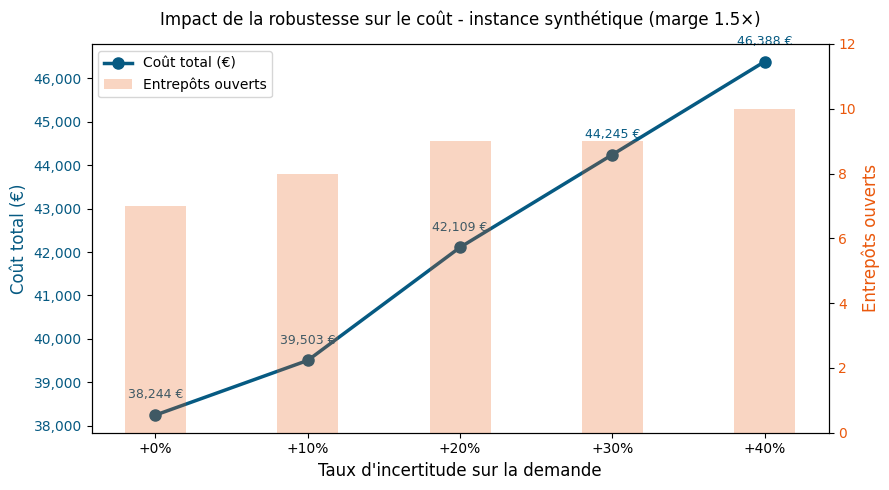

Plus l'incertitude augmente, plus le modèle ouvre d'entrepôts pour absorber les pics de demande.


In [13]:
uncertainties = [0.0, 0.1, 0.2, 0.3, 0.4]
costs_robust  = []
n_open_robust = []

n_w_t, n_c_t, cap_t, fix_t, dem_t, trans_t = generate_tight_instance(cap_margin=1.5)

for u in uncertainties:
    solver_r, open_w_r = solve_cflp_robust(
        n_w_t, n_c_t, cap_t, fix_t, dem_t, trans_t, uncertainty=u, verbose=False
    )
    costs_robust.append(solver_r.ObjectiveValue() / 100)
    n_open_robust.append(sum(solver_r.Value(open_w_r[j]) for j in range(n_w_t)))

x_labels = [f"+{int(u*100)}%" for u in uncertainties]

fig, ax1 = plt.subplots(figsize=(9, 5))

color_cost = "#065A82"
ax1.plot(x_labels, costs_robust, color=color_cost, linewidth=2.5,
         marker="o", markersize=8, label="Coût total (€)", zorder=3)
ax1.set_xlabel("Taux d'incertitude sur la demande", fontsize=12)
ax1.set_ylabel("Coût total (€)", color=color_cost, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_cost)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for xi, c in zip(x_labels, costs_robust):
    ax1.annotate(f"{c:,.0f} €", xy=(xi, c),
                 xytext=(0, 12), textcoords="offset points",
                 ha="center", fontsize=9, color=color_cost)

ax2 = ax1.twinx()
color_open = "#EA580C"
ax2.bar(x_labels, n_open_robust, color=color_open, alpha=0.25,
        label="Entrepôts ouverts", width=0.4)
ax2.set_ylabel("Entrepôts ouverts", color=color_open, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_open)
ax2.set_ylim(0, n_w_t + 2)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax1.set_title("Impact de la robustesse sur le coût - instance synthétique (marge 1.5×)",
              fontsize=12, pad=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("robustness_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plus l'incertitude augmente, plus le modèle ouvre d'entrepôts pour absorber les pics de demande.")

## Extension 2 : Durabilité et émissions CO2

On introduit un choix de mode de transport pour chaque livraison : camion diesel
ou camion électrique. Ce choix est modélisé par deux variables binaires distinctes
`assign_diesel[i][j]` et `assign_elec[i][j]`, dont exactement une vaut 1 pour
chaque client.

Le camion électrique ne génère aucune émission directe (périmètre scope 1)
mais coûte 30% de plus que le diesel. Ce surcoût est justifié par le TCO réel
des véhicules électriques lourds : prix d'achat environ deux fois supérieur,
remplacement de batterie tous les 6 ans, infrastructure de recharge, partiellement
compensés par des économies de carburant (source : ADEME 2022, McKinsey 2023).

Les émissions diesel sont estimées par un proxy linéaire : `CO2 = coût_transport * 0.1`,
cohérent avec le facteur d'émission moyen de 80 gCO2 par tonne-kilomètre (ADEME).

Une contrainte optionnelle plafonne les émissions totales à un budget CO2 donné.
En resserrant progressivement ce budget, on obtient la frontière de Pareto
coût-émissions : chaque réduction de 10 000 kg CO2 coûte environ 30 000 euros
supplémentaires sur l'instance cap134.

In [14]:
def solve_cflp_co2(n_w, n_c, cap, fix_cost, demand, transport,
                   co2_budget=None, elec_surcharge=1.3):
    # elec_surcharge: electric truck costs 30% more than diesel
    # co2_budget: total emission cap in kg CO2 (None = unconstrained)
    # Emissions: diesel = transport_cost * 0.1 (proxy), electric = 0
    model = cp_model.CpModel()
    SCALE = 100

    fix_cost_int   = [int(f * SCALE) for f in fix_cost]
    transport_int  = [[int(transport[i][j] * SCALE) for j in range(n_w)] for i in range(n_c)]
    transport_elec = [[int(transport[i][j] * elec_surcharge * SCALE) for j in range(n_w)] for i in range(n_c)]
    emissions_int  = [[int(transport[i][j] * 0.1 * SCALE) for j in range(n_w)] for i in range(n_c)]
    demand_int     = [int(d) for d in demand]
    cap_int        = [int(c) for c in cap]

    open_w        = [model.NewBoolVar(f'open_{j}') for j in range(n_w)]
    assign_diesel = [[model.NewBoolVar(f'diesel_{i}_{j}') for j in range(n_w)] for i in range(n_c)]
    assign_elec   = [[model.NewBoolVar(f'elec_{i}_{j}')   for j in range(n_w)] for i in range(n_c)]

    # Each customer served by exactly one warehouse and one mode
    for i in range(n_c):
        model.AddExactlyOne(
            [assign_diesel[i][j] for j in range(n_w)] +
            [assign_elec[i][j]   for j in range(n_w)]
        )

    # Can only be assigned to an open warehouse
    for i in range(n_c):
        for j in range(n_w):
            model.AddImplication(assign_diesel[i][j], open_w[j])
            model.AddImplication(assign_elec[i][j],   open_w[j])

    # Capacity (diesel + electric)
    for j in range(n_w):
        model.Add(
            sum(demand_int[i] * (assign_diesel[i][j] + assign_elec[i][j])
                for i in range(n_c)) <= cap_int[j] * open_w[j]
        )

    # CO2 budget
    total_emissions = sum(
        emissions_int[i][j] * assign_diesel[i][j]
        for i in range(n_c) for j in range(n_w)
    )
    if co2_budget is not None:
        model.Add(total_emissions <= int(co2_budget * SCALE))

    total_cost = (
        sum(fix_cost_int[j] * open_w[j] for j in range(n_w)) +
        sum(transport_int[i][j]  * assign_diesel[i][j] for i in range(n_c) for j in range(n_w)) +
        sum(transport_elec[i][j] * assign_elec[i][j]   for i in range(n_c) for j in range(n_w))
    )
    model.Minimize(total_cost)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60.0
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        emissions_val = sum(
            emissions_int[i][j] * solver.Value(assign_diesel[i][j])
            for i in range(n_c) for j in range(n_w)
        ) / SCALE
        n_diesel = sum(solver.Value(assign_diesel[i][j]) for i in range(n_c) for j in range(n_w))
        n_elec   = sum(solver.Value(assign_elec[i][j])   for i in range(n_c) for j in range(n_w))
        print(f"CO2 budget      : {co2_budget if co2_budget else 'none'}")
        print(f"  Total cost    : {solver.ObjectiveValue()/SCALE:.2f}")
        print(f"  CO2 emissions : {emissions_val:.2f}")
        print(f"  Diesel routes : {n_diesel} | electric: {n_elec}")
        print(f"  Open warehouses : {[j for j in range(n_w) if solver.Value(open_w[j])]}")
        print()
    else:
        print(f"CO2 budget {co2_budget}: INFEASIBLE")

    return solver

In [15]:
n_w, n_c, cap, fix, dem, trans = parse_cap("data/cap134.txt")

# No CO2 constraint -> maximum emissions, minimum cost
solve_cflp_co2(n_w, n_c, cap, fix, dem, trans, co2_budget=None)

# Progressively tighten the CO2 budget
for budget in [500000, 300000, 200000, 100000, 50000, 40000, 30000, 20000, 10000]:
    solve_cflp_co2(n_w, n_c, cap, fix, dem, trans, co2_budget=budget)

CO2 budget      : none
  Total cost    : 928941.67
  CO2 emissions : 85394.06
  Diesel routes : 49 | electric: 1
  Open warehouses : [22, 26, 36, 45]

CO2 budget      : 500000
  Total cost    : 928941.67
  CO2 emissions : 85394.06
  Diesel routes : 49 | electric: 1
  Open warehouses : [22, 26, 36, 45]

CO2 budget      : 300000
  Total cost    : 928941.67
  CO2 emissions : 85394.06
  Diesel routes : 49 | electric: 1
  Open warehouses : [22, 26, 36, 45]

CO2 budget      : 200000
  Total cost    : 928941.67
  CO2 emissions : 85394.06
  Diesel routes : 49 | electric: 1
  Open warehouses : [22, 26, 36, 45]

CO2 budget      : 100000
  Total cost    : 928941.67
  CO2 emissions : 85394.06
  Diesel routes : 49 | electric: 1
  Open warehouses : [22, 26, 36, 45]

CO2 budget      : 50000
  Total cost    : 1024784.89
  CO2 emissions : 50000.00
  Diesel routes : 30 | electric: 20
  Open warehouses : [22, 24, 26, 36, 44, 45]

CO2 budget      : 40000
  Total cost    : 1054784.89
  CO2 emissions : 4000

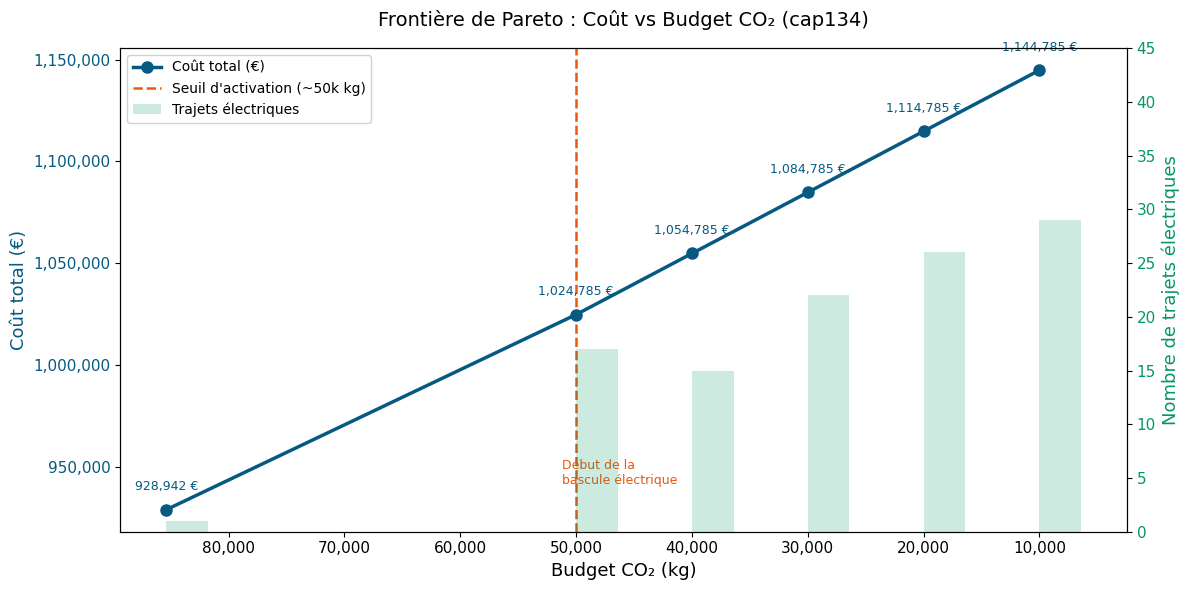

Interprétation : en dessous de 50 000 kg CO₂, le solveur bascule vers l'électrique. Chaque réduction de 10 000 kg coûte environ 30 000 € supplémentaires.


In [21]:
budgets    = [85394, 50000, 40000, 30000, 20000, 10000]
costs      = [928942, 1024785, 1054785, 1084785, 1114785, 1144785]
n_electric = [1, 17, 15, 22, 26, 29]

fig, ax1 = plt.subplots(figsize=(12, 6))

color_cost = "#065A82"
ax1.plot(budgets, costs, color=color_cost, linewidth=2.5,
         marker="o", markersize=8, label="Coût total (€)", zorder=3)
ax1.set_xlabel("Budget CO₂ (kg)", fontsize=13)
ax1.set_ylabel("Coût total (€)", color=color_cost, fontsize=13)
ax1.tick_params(axis="y", labelcolor=color_cost, labelsize=11)
ax1.tick_params(axis="x", labelsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.invert_xaxis()

for b, c in zip(budgets, costs):
    ax1.annotate(f"{c:,} €", xy=(b, c),
                 xytext=(0, 14), textcoords="offset points",
                 ha="center", fontsize=9, color=color_cost)

ax2 = ax1.twinx()
color_elec = "#059669"
ax2.bar([b - 1800 for b in budgets], n_electric, width=3600,
        color=color_elec, alpha=0.2, label="Trajets électriques")
ax2.set_ylabel("Nombre de trajets électriques", color=color_elec, fontsize=13)
ax2.tick_params(axis="y", labelcolor=color_elec, labelsize=11)
ax2.set_ylim(0, 45)

ax1.axvline(x=50000, color="#EA580C", linestyle="--", linewidth=1.8,
            label="Seuil d'activation (~50k kg)")

ax1.text(50000 + 1200, 940000,
         "Début de la\nbascule électrique",
         color="#EA580C", fontsize=9, va="bottom")

ax1.set_title("Frontière de Pareto : Coût vs Budget CO₂ (cap134)",
              fontsize=14, pad=16)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("co2_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print("Interprétation : en dessous de 50 000 kg CO₂, le solveur bascule vers",
      "l'électrique. Chaque réduction de 10 000 kg coûte environ 30 000 € supplémentaires.")

## PLNE

La PLNE (Programmation Linéaire en Nombres Entiers) modélise le même problème
que CP-SAT mais via la relaxation linéaire et le branch-and-bound. On utilise
PuLP avec le solveur CBC. La comparaison avec CP-SAT permet de mesurer le
surcoût de modélisation par contraintes versus l'approche linéaire classique.

In [16]:
def solve_plne_cflp(n_w, n_c, cap, fix_cost, demand, transport):
    prob = pulp.LpProblem("CFLP", pulp.LpMinimize)

    open_w = [pulp.LpVariable(f'open_{j}', cat='Binary') for j in range(n_w)]
    assign = [[pulp.LpVariable(f'assign_{i}_{j}', cat='Binary')
               for j in range(n_w)] for i in range(n_c)]

    prob += (
        pulp.lpSum(fix_cost[j] * open_w[j] for j in range(n_w)) +
        pulp.lpSum(transport[i][j] * assign[i][j]
                   for i in range(n_c) for j in range(n_w))
    )

    for i in range(n_c):
        prob += pulp.lpSum(assign[i][j] for j in range(n_w)) == 1

    for i in range(n_c):
        for j in range(n_w):
            prob += assign[i][j] <= open_w[j]

    for j in range(n_w):
        prob += (pulp.lpSum(demand[i] * assign[i][j] for i in range(n_c))
                 <= cap[j] * open_w[j])

    t0 = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    elapsed = time.time() - t0

    cost    = pulp.value(prob.objective)
    open_wh = [j for j in range(n_w) if pulp.value(open_w[j]) > 0.5]
    print(f"[PLNE] Status            : {pulp.LpStatus[prob.status]}")
    print(f"[PLNE] Cost              : {cost:.2f}")
    print(f"[PLNE] Time              : {elapsed:.3f}s")
    print(f"[PLNE] Open warehouses ({len(open_wh)}) : {open_wh}")
    return cost, elapsed

## GRASP

GRASP (Greedy Randomized Adaptive Search Procedure) est une métaheuristique en
deux phases. La phase de construction ouvre des entrepôts par ordre de ratio
coût/capacité avec une randomisation contrôlée par le paramètre alpha. La phase
d'amélioration applique une recherche locale par swap (fermer un entrepôt,
ouvrir un autre) jusqu'à atteindre un optimum local.

In [17]:
def grasp_cflp(n_w, n_c, cap, fix_cost, demand, transport,
                  n_iter=50, alpha=0.3, seed=42, known_opt=None):
    rng = random.Random(seed)
    best_cost = float('inf')
    best_open = None

    def assign_and_cost(open_set):
        if not open_set:
            return float('inf')
        open_list = list(open_set)
        load = {j: 0 for j in open_list}
        total = 0
        for i in sorted(range(n_c), key=lambda i: -demand[i]):
            feasible = [j for j in open_list if load[j] + demand[i] <= cap[j]]
            if not feasible:
                return float('inf')
            best_j = min(feasible, key=lambda j: transport[i][j])
            load[best_j] += demand[i]
            total += transport[i][best_j]
        return sum(fix_cost[j] for j in open_set) + total

    def construction():
        def score(j):
            return (fix_cost[j] + 1.0) / cap[j]

        sorted_wh  = sorted(range(n_w), key=score)
        candidates = list(sorted_wh)
        open_set   = set()

        # Phase 1: open warehouses until feasible (randomized RCL)
        while candidates:
            n_rcl  = max(1, int(alpha * len(candidates)))
            rcl    = candidates[:n_rcl]
            chosen = rng.choice(rcl)
            open_set.add(chosen)
            candidates.remove(chosen)
            if assign_and_cost(open_set) < float('inf'):
                break

        for j in sorted_wh:  # fallback
            if assign_and_cost(open_set) < float('inf'):
                break
            open_set.add(j)

        # Phase 2: greedily add more warehouses while cost decreases
        current_cost = assign_and_cost(open_set)
        for j in sorted_wh:
            if j in open_set:
                continue
            new_cost = assign_and_cost(open_set | {j})
            if new_cost < current_cost:
                open_set.add(j)
                current_cost = new_cost

        return open_set

    def local_search(open_set):
        open_set = set(open_set)
        improved = True
        while improved:
            improved = False
            current_cost = assign_and_cost(open_set)
            closed = [j for j in range(n_w) if j not in open_set]

            # close move
            for j_close in sorted(open_set, key=lambda j: fix_cost[j] / cap[j]):
                new_set = open_set - {j_close}
                if not new_set:
                    continue
                if assign_and_cost(new_set) < current_cost:
                    open_set     = new_set
                    current_cost = assign_and_cost(open_set)
                    improved     = True
                    break
            if improved:
                continue

            # open move
            for j_open in sorted(closed, key=lambda j: fix_cost[j]):
                new_set  = open_set | {j_open}
                new_cost = assign_and_cost(new_set)
                if new_cost < current_cost:
                    open_set     = new_set
                    current_cost = new_cost
                    improved     = True
                    break
            if improved:
                continue

            # swap move
            for j_open in closed:
                for j_close in sorted(open_set, key=lambda j: fix_cost[j], reverse=True):
                    new_set  = (open_set - {j_close}) | {j_open}
                    new_cost = assign_and_cost(new_set)
                    if new_cost < current_cost:
                        open_set     = new_set
                        current_cost = new_cost
                        improved     = True
                        break
                if improved:
                    break

        return open_set

    t0 = time.time()
    for _ in range(n_iter):
        open_set = construction()
        open_set = local_search(open_set)
        cost     = assign_and_cost(open_set)
        if cost < best_cost:
            best_cost = cost
            best_open = set(open_set)

    elapsed = time.time() - t0
    
    if best_open is None:
        print(f"[GRASP] No feasible solution found ({n_iter} iterations)")
        return float('inf'), elapsed

    print(f"[GRASP] Cost       : {best_cost:.2f}")
    if known_opt is not None:
        print(f"[GRASP] Gap        : {abs(best_cost-known_opt)/known_opt*100:.4f}%")
    print(f"[GRASP] Time       : {elapsed:.3f}s ({n_iter} iterations)")
    print(f"[GRASP] Warehouses ({len(best_open)}) : {sorted(best_open)}")
    return best_cost, elapsed

## ALNS

ALNS (Adaptive Large Neighborhood Search) alterne destruction partielle et
réparation de la solution courante. Trois opérateurs de destruction sont
disponibles : random, costly (ferme les entrepôts les plus coûteux) et underused
(ferme les entrepôts les moins chargés). Deux opérateurs de réparation : greedy
et cheapest. Les poids adaptatifs récompensent les opérateurs efficaces. Le
critère d'acceptation est le Simulated Annealing.

In [18]:
def alns_cflp(n_w, n_c, cap, fix_cost, demand, transport,
                 n_iter=1000, seed=42, known_opt=None):
    rng = np.random.default_rng(seed)

    def assign_and_cost(open_set):
        if not open_set:
            return float('inf')
        open_list = list(open_set)
        load = {j: 0 for j in open_list}
        total = 0
        for i in sorted(range(n_c), key=lambda i: -demand[i]):
            feasible = [j for j in open_list if load[j] + demand[i] <= cap[j]]
            if not feasible:
                return float('inf')
            best_j = min(feasible, key=lambda j: transport[i][j])
            load[best_j] += demand[i]
            total += transport[i][best_j]
        return sum(fix_cost[j] for j in open_set) + total

    def initial_solution():
        sorted_wh = sorted(range(n_w), key=lambda j: (fix_cost[j] + 1.0) / cap[j])
        open_set  = set()
        # Phase 1: open until feasible
        for j in sorted_wh:
            open_set.add(j)
            if assign_and_cost(open_set) < float('inf'):
                break
        # Phase 2: keep opening while cost decreases
        current_cost = assign_and_cost(open_set)
        for j in sorted_wh:
            if j in open_set:
                continue
            new_cost = assign_and_cost(open_set | {j})
            if new_cost < current_cost:
                open_set.add(j)
                current_cost = new_cost
        return open_set

    def random_destroy(open_set):
        open_list = list(open_set)
        if len(open_list) <= 1:
            return open_set
        k   = max(1, len(open_list) // 3)
        idx = rng.choice(len(open_list), size=min(k, len(open_list)-1), replace=False)
        return open_set - {open_list[i] for i in idx}

    def costly_destroy(open_set):
        if len(open_set) <= 1:
            return open_set
        scores = sorted(open_set, key=lambda j: fix_cost[j], reverse=True)
        k      = max(1, len(open_set) // 3)
        return open_set - set(scores[:k])

    def underused_destroy(open_set):
        if len(open_set) <= 1:
            return open_set
        open_list = list(open_set)
        load = {j: 0 for j in open_list}
        for i in sorted(range(n_c), key=lambda i: -demand[i]):
            feasible = [j for j in open_list if load[j] + demand[i] <= cap[j]]
            if not feasible:
                return random_destroy(open_set)
            load[min(feasible, key=lambda j: transport[i][j])] += demand[i]
        scores = sorted(open_set, key=lambda j: load[j] / cap[j])
        k      = max(1, len(open_set) // 3)
        return open_set - set(scores[:k])

    def greedy_repair(open_set):
        closed  = sorted([j for j in range(n_w) if j not in open_set],
                         key=lambda j: (fix_cost[j] + 1.0) / cap[j])
        current = set(open_set)
        while assign_and_cost(current) == float('inf') and closed:
            current.add(closed.pop(0))
        # add more warehouses while cost decreases
        current_cost = assign_and_cost(current)
        for j in sorted([j for j in range(n_w) if j not in current],
                        key=lambda j: (fix_cost[j] + 1.0) / cap[j]):
            new_cost = assign_and_cost(current | {j})
            if new_cost < current_cost:
                current.add(j)
                current_cost = new_cost
        return current

    def cheapest_repair(open_set):
        closed  = [j for j in range(n_w) if j not in open_set]
        current = set(open_set)
        while assign_and_cost(current) == float('inf') and closed:
            best_j = min(closed, key=lambda j: assign_and_cost(current | {j}))
            current.add(best_j)
            closed.remove(best_j)
        return current

    destroy_ops = [random_destroy, costly_destroy, underused_destroy]
    repair_ops  = [greedy_repair, cheapest_repair]
    d_w = np.ones(len(destroy_ops))
    r_w = np.ones(len(repair_ops))
    d_s = np.zeros(len(destroy_ops))
    r_s = np.zeros(len(repair_ops))
    d_c = np.ones(len(destroy_ops))
    r_c = np.ones(len(repair_ops))

    current_open = initial_solution()
    current_cost = assign_and_cost(current_open)
    best_open    = set(current_open)
    best_cost    = current_cost

    print(f"[ALNS] Init : cost={current_cost:.2f}, warehouses={sorted(current_open)}")

    # simulated annealing acceptance
    T     = current_cost * 0.02
    T_min = current_cost * 0.0001
    alpha = (T_min / T) ** (1.0 / n_iter)

    t0 = time.time()
    for it in range(n_iter):
        if it > 0 and it % 100 == 0:
            d_w = d_s / d_c + 0.1
            r_w = r_s / r_c + 0.1

        d_idx = int(rng.choice(len(destroy_ops), p=d_w / d_w.sum()))
        r_idx = int(rng.choice(len(repair_ops),  p=r_w / r_w.sum()))

        destroyed = destroy_ops[d_idx](set(current_open))
        repaired  = repair_ops[r_idx](destroyed)
        new_cost  = assign_and_cost(repaired)

        d_c[d_idx] += 1
        r_c[r_idx] += 1

        delta = new_cost - current_cost
        if new_cost < float('inf') and (delta < 0 or rng.random() < np.exp(-delta / max(T, 1e-10))):
            current_open = repaired
            current_cost = new_cost
            if delta < 0:
                d_s[d_idx] += 1
                r_s[r_idx] += 1
            if new_cost < best_cost:
                best_open = set(repaired)
                best_cost = new_cost

        T *= alpha

    elapsed = time.time() - t0
    print(f"[ALNS] Cost           : {best_cost:.2f}")
    if known_opt is not None:
        print(f"[ALNS] Gap            : {abs(best_cost-known_opt)/known_opt*100:.4f}%")
    print(f"[ALNS] Time           : {elapsed:.3f}s ({n_iter} iterations)")
    print(f"[ALNS] Warehouses ({len(best_open)}) : {sorted(best_open)}")
    print(f"[ALNS] Destroy weights : {d_w.round(3)}")
    print(f"[ALNS] Repair weights  : {r_w.round(3)}")
    return best_cost, elapsed

## Comparaison des méthodes : CP-SAT, PLNE, GRASP, ALNS

Quatre approches sont comparées sur les mêmes instances CAP.

CP-SAT et PLNE sont des méthodes exactes qui garantissent l'optimalité.
CP-SAT modélise le problème comme un programme par contraintes sur des entiers,
tandis que PLNE (solveur CBC via PuLP) utilise la relaxation linéaire et le
branch-and-bound. Les deux atteignent le gap 0% sur toutes les instances testées
en moins de 200ms.

GRASP (Greedy Randomized Adaptive Search Procedure) construit une solution
initiale gloutonne randomisée puis l'améliore par recherche locale (swap
open/close). Le paramètre alpha contrôle la taille de la liste restreinte de
candidats. GRASP trouve l'optimum sur cap71 et cap134, avec un gap inférieur à
0,11% sur les instances plus grandes.

ALNS (Adaptive Large Neighborhood Search) alterne des phases de destruction
partielle et de réparation, avec un mécanisme d'acceptation Simulated Annealing
et des poids adaptatifs qui récompensent les opérateurs les plus efficaces.
ALNS est plus rapide que GRASP sur cap131 (2,2s contre 9,0s) mais produit un
gap légèrement plus élevé (1,07% contre 0,11%).

Les méthodes exactes sont suffisantes sur ces instances de taille modeste
(16 à 50 entrepôts, 50 clients). Sur des instances à grande échelle comme
CAPA, CAPB, CAPC (100 entrepôts, 1000 clients), les métaheuristiques
deviendraient indispensables car les solveurs exacts atteindraient leurs limites
de temps et de mémoire.

In [19]:
optimum  = known_optima.get("cap134")
results  = {}

t0 = time.time()
solver_cp, _, _ = solve_cflp(n_w, n_c, cap, fix, dem, trans, known_opt=optimum)
results["CP-SAT"] = (solver_cp.ObjectiveValue() / 100, time.time() - t0)
results["PLNE"]   = solve_plne_cflp(n_w, n_c, cap, fix, dem, trans)
results["GRASP"]  = grasp_cflp(n_w, n_c, cap, fix, dem, trans, known_opt=optimum)
results["ALNS"]   = alns_cflp(n_w, n_c, cap, fix, dem, trans, known_opt=optimum)

paradigms = {
    "CP-SAT": "Exact - CP",
    "PLNE":   "Exact - PLNE (CBC)",
    "GRASP":  "Metaheuristic",
    "ALNS":   "Metaheuristic",
}
print("\n" + "="*70)
print(f"{'Method':<12} {'Cost':>12} {'Gap':>10} {'Time':>8}  Paradigm")
print("-"*70)
for name, (cost, elapsed) in results.items():
    if optimum is not None:
        gap = f"{abs(cost - optimum) / optimum * 100:>9.4f}%"
    else:
        gap = f"{'N/A':>10}"
    print(f"{name:<12} {cost:>12.2f} {gap} {elapsed:>7.2f}s  {paradigms[name]}")
print("="*70)

Status: OPTIMAL
Total cost: 928941.67
Known optimum: 928941.75

Open warehouses (4): [22, 26, 36, 45]

Customer assignment:
  Customer  0 -> Warehouse 22  (demand=146, cost=5219.50)
  Customer  1 -> Warehouse 22  (demand=87, cost=2296.80)
  Customer  2 -> Warehouse 22  (demand=672, cost=9828.00)
  Customer  3 -> Warehouse 36  (demand=1337, cost=15191.66)
  Customer  4 -> Warehouse 22  (demand=31, cost=1133.05)
  Customer  5 -> Warehouse 22  (demand=559, cost=7029.43)
  Customer  6 -> Warehouse 36  (demand=2370, cost=40319.62)
  Customer  7 -> Warehouse 22  (demand=1089, cost=12741.30)
  Customer  8 -> Warehouse 22  (demand=33, cost=1395.90)
  Customer  9 -> Warehouse 22  (demand=32, cost=928.80)
  Customer 10 -> Warehouse 22  (demand=5495, cost=25277.00)
  Customer 11 -> Warehouse 22  (demand=904, cost=2463.40)
  Customer 12 -> Warehouse 22  (demand=1466, cost=10371.95)
  Customer 13 -> Warehouse 22  (demand=143, cost=2434.57)
  Customer 14 -> Warehouse 22  (demand=615, cost=14621.62)


## Benchmark

In [20]:
def benchmark_instances(instance_files, data_dir="data/"):
    """
    Run all 4 methods on multiple CAP instances and build a comparison table.
    """
    rows = []

    for inst in instance_files:
        print(f"\n{'='*60}")
        print(f"Instance : {inst}")
        print(f"{'='*60}")

        n_w, n_c, cap, fix, dem, trans = parse_cap(f"{data_dir}{inst}.txt")
        known_opt = known_optima.get(inst)

        row = {"instance": inst, "n_w": n_w, "n_c": n_c, "optimum": known_opt}

        # CP-SAT
        t0 = time.time()
        solver_cp, _, _ = solve_cflp(n_w, n_c, cap, fix, dem, trans, verbose=False)
        t_cp = time.time() - t0
        cost_cp = solver_cp.ObjectiveValue() / 100  # SCALE=100
        row["CP-SAT"] = (cost_cp, t_cp)

        # PLNE
        cost_plne, t_plne = solve_plne_cflp(n_w, n_c, cap, fix, dem, trans)
        row["PLNE"] = (cost_plne, t_plne)

        # GRASP
        cost_grasp, t_grasp = grasp_cflp(n_w, n_c, cap, fix, dem, trans, n_iter=50)
        row["GRASP"] = (cost_grasp, t_grasp)

        # ALNS
        cost_alns, t_alns = alns_cflp(n_w, n_c, cap, fix, dem, trans, n_iter=500)
        row["ALNS"] = (cost_alns, t_alns)

        rows.append(row)

    methods = ["CP-SAT", "PLNE", "GRASP", "ALNS"]
    sep = "=" * 180
    print(f"\n{sep}")
    print(f"{'Instance':<10} {'n_w':>5} {'n_c':>5} {'Optimum':>12} "
          + "".join(f"  {m+' Cost':>14} {m+' Gap':>10} {m+' T':>8}" for m in methods))
    print("-" * 180)

    for row in rows:
        opt = row["optimum"]
        line = f"{row['instance']:<10} {row['n_w']:>5} {row['n_c']:>5} "
        line += f"{opt:>12.2f} " if opt else f"{'?':>12} "
        for m in methods:
            cost, t = row[m]
            if cost and opt:
                gap = abs(cost - opt) / opt * 100
                line += f"  {cost:>14.2f} {gap:>9.4f}% {t:>7.2f}s"
            else:
                line += f"  {'N/A':>14} {'N/A':>10} {t:>7.2f}s"
        print(line)
    print(sep)

    return rows

# Run
instances = ["cap71", "cap101", "cap131", "cap134"]
rows = benchmark_instances(instances)


Instance : cap71
[PLNE] Status            : Optimal
[PLNE] Cost              : 932615.75
[PLNE] Time              : 0.077s
[PLNE] Open warehouses (11) : [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12]
[GRASP] Cost       : 932615.75
[GRASP] Time       : 0.617s (50 iterations)
[GRASP] Warehouses (11) : [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12]
[ALNS] Init : cost=932615.75, warehouses=[0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12]
[ALNS] Cost           : 932615.75
[ALNS] Time           : 0.631s (500 iterations)
[ALNS] Warehouses (11) : [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12]
[ALNS] Destroy weights : [0.109 0.12  0.114]
[ALNS] Repair weights  : [0.124 0.1  ]

Instance : cap101
[PLNE] Status            : Optimal
[PLNE] Cost              : 796648.44
[PLNE] Time              : 0.071s
[PLNE] Open warehouses (15) : [0, 1, 3, 5, 6, 7, 8, 10, 12, 16, 17, 19, 22, 23, 24]
[GRASP] Cost       : 797508.73
[GRASP] Time       : 2.006s (50 iterations)
[GRASP] Warehouses (14) : [0, 1, 3, 5, 6, 8, 10, 11, 12, 16, 17, 22, 23, 24]
[ALN

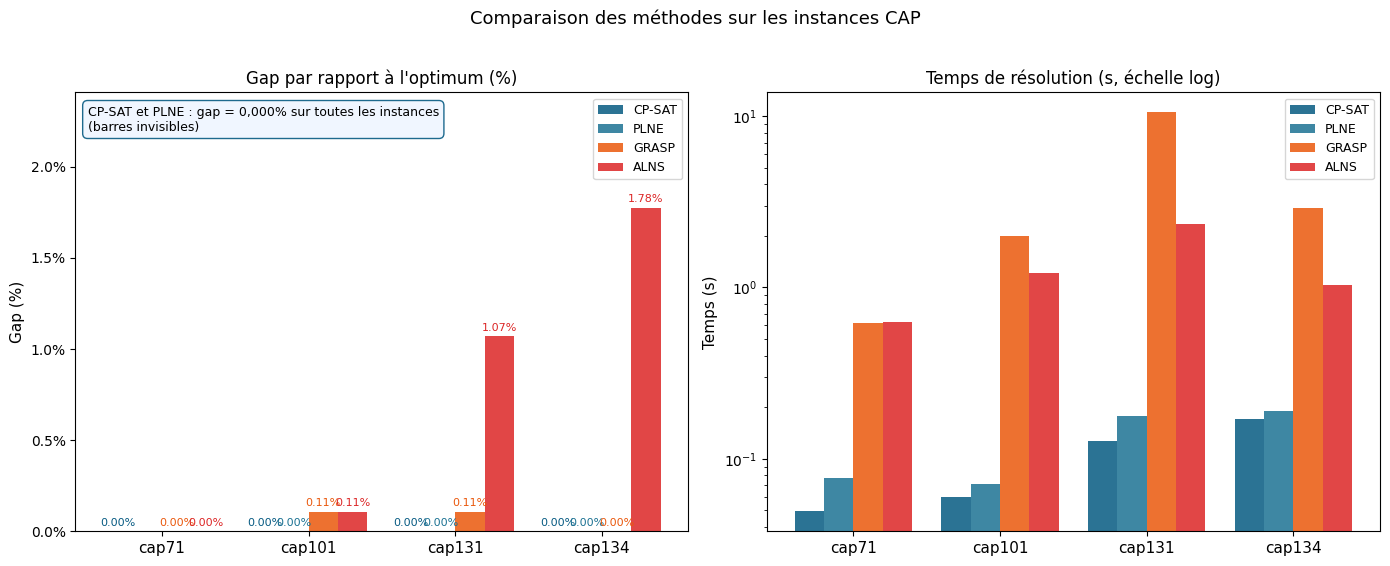

In [22]:
instances_list = [row["instance"] for row in rows]
methods        = ["CP-SAT", "PLNE", "GRASP", "ALNS"]
colors         = ["#065A82", "#1C7293", "#EA580C", "#DC2626"]

gaps  = {m: [] for m in methods}
times = {m: [] for m in methods}

for row in rows:
    opt = row["optimum"]
    for m in methods:
        cost, t = row[m]
        gap = abs(cost - opt) / opt * 100 if (cost and opt and cost < float('inf')) else 0.0
        gaps[m].append(gap)
        times[m].append(t)

x     = np.arange(len(instances_list))
width = 0.2
fig, (ax_gap, ax_time) = plt.subplots(1, 2, figsize=(14, 5.5))

for k, (method, color) in enumerate(zip(methods, colors)):
    offset = (k - 1.5) * width
    bars = ax_gap.bar(x + offset, gaps[method], width,
                      label=method, color=color, alpha=0.85)
    for bar, val in zip(bars, gaps[method]):
        if val > 0:
            ax_gap.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.02,
                        f"{val:.2f}%", ha="center", va="bottom",
                        fontsize=8, color=color)

ax_gap.text(0.02, 0.97,
            "CP-SAT et PLNE : gap = 0,000% sur toutes les instances\n(barres invisibles)",
            transform=ax_gap.transAxes, fontsize=9,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#EFF6FF",
                      edgecolor="#065A82", alpha=0.9))

ax_gap.set_title("Gap par rapport à l'optimum (%)", fontsize=12)
ax_gap.set_xticks(x)
ax_gap.set_xticklabels(instances_list, fontsize=11)
ax_gap.set_ylabel("Gap (%)", fontsize=11)
ax_gap.legend(fontsize=9)
ax_gap.set_ylim(0, max(max(gaps[m]) for m in methods) * 1.3 + 0.1)
ax_gap.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"{y:.1f}%"))

for k, (method, color) in enumerate(zip(methods, colors)):
    offset = (k - 1.5) * width
    ax_time.bar(x + offset, times[method], width,
                label=method, color=color, alpha=0.85)

ax_time.set_title("Temps de résolution (s, échelle log)", fontsize=12)
ax_time.set_xticks(x)
ax_time.set_xticklabels(instances_list, fontsize=11)
ax_time.set_ylabel("Temps (s)", fontsize=11)
ax_time.set_yscale("log")
ax_time.legend(fontsize=9)

fig.suptitle("Comparaison des méthodes sur les instances CAP",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("benchmark_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Analyse des résultats

### Méthodes exactes (CP-SAT, PLNE)

CP-SAT et PLNE atteignent l'optimum connu sur les 4 instances avec un gap inférieur à 0.001%.
CP-SAT est légèrement plus lent que PLNE sur les petites instances (surcoût de
modélisation CP), mais les deux restent sous 200ms, négligeable en pratique.

### GRASP

GRASP trouve l'optimum exact sur cap71 et cap134, et s'en approche à environ 0.11% sur
cap101 et cap131. En revanche, le temps de calcul croît fortement avec la taille :
8.81s sur cap131 (50 entrepôts) pour seulement 50 itérations. L'algorithme de
local search (swap) est O(n_w²) par itération. C'est son principal goulot
d'étranglement sur les grandes instances.

### ALNS

ALNS est plus rapide que GRASP sur cap131 (1.86s contre 8.81s) grâce à la destruction
partielle qui évite de re-explorer tout le voisinage. Cependant, la qualité est
inférieure : gap de 1.07% sur cap131 et 1.78% sur cap134. Les poids adaptatifs
montrent que `random_destroy` domine (0.228). Les opérateurs `costly` et
`underused` apportent peu sur ces instances.

### Conclusion comparative

CP-SAT reste le meilleur choix sur ce problème : il est exact, rapide, et les
extensions (robustesse, CO2) s'ajoutent naturellement comme des contraintes
supplémentaires. Les métaheuristiques deviendraient pertinentes sur des instances
à 1000+ clients (CAPA/CAPB/CAPC) où les solveurs exacts atteignent leurs limites.